In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\user\OneDrive\Documents\superstore_db.csv")

In [5]:
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Unit Price,Revenue
0,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furni,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,130.980000,261.9600
1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furni,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,0.0000,243.980000,731.9400
2,CA-2016-138688,06-12-2016,16-06-2016,Second Class,DV-13045,United States,Los Angeles,California,90036,West,OFF-LA-10000240,OfficeSupply,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,7.310000,14.6200
3,US-2015-108966,10-11-2015,18-10-2015,Standard Class,SO-20335,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furni,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,191.515500,957.5775
4,US-2015-108966,10-11-2015,18-10-2015,Standard Class,SO-20335,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,OfficeSupply,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11.184000,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12612,CA-2016-272483,21-11-2015,23-11-2015,Standard Class,SB-20170,United States,Miami,Florida,33180,South,FUR-FU-10000732,Furni,Furnishings,Eldon 200 Class Desk Accessories,1257.3235,6,0.45,0.0000,209.553917,1257.3235
12613,US-2017-668083,24-02-2014,03-01-2014,Standard Class,LC-16930,United States,Holland,Michigan,49423,Central,TEC-MA-10002178,Tech,Machines,Cisco CP-7937G Unified IP Conference Station P...,0.0100,4,0.32,0.0000,0.002500,0.0100
12614,US-2014-554326,29-05-2014,31-05-2014,Same Day,CC-12430,United States,Columbia,South Carolina,29203,South,OFF-AR-10004691,OfficeSupply,Art,Boston 1730 StandUp Electric Pencil Sharpener,815.0028,10,0.50,-34.0315,81.500280,815.0028
12615,CA-2017-698123,05-04-2016,05-08-2016,Second Class,MS-17770,United States,Saint Charles,Missouri,63301,Central,FUR-CH-10001797,Furni,Chairs,"Safco Chair Connectors, 6/Carton",211.2283,5,0.45,-18.5582,42.245660,211.2283


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

In [7]:
df['Order Date']

0       2016-11-08
1       2016-11-08
2       2016-06-12
3       2015-10-11
4       2015-10-11
           ...    
12612          NaT
12613          NaT
12614          NaT
12615   2016-05-04
12616          NaT
Name: Order Date, Length: 12617, dtype: datetime64[ns]

In [15]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Unit Price', 'Revenue'],
      dtype='object')


In [12]:
df.columns = df.columns.str.strip()

In [13]:
print(df['Revenue'].head())

0    261.9600
1    731.9400
2     14.6200
3    957.5775
4     22.3680
Name: Revenue, dtype: float64


In [17]:
# Average Order Value Per Customer
avg_order_value = df.groupby('Customer ID')['Revenue'].mean()

print(avg_order_value)

Customer ID
AA-10315    499.782053
AA-10375    191.506621
AA-10480    146.656946
AA-10645    243.419076
AB-10015    218.143145
               ...    
XP-21865     81.885103
YC-21895    454.531667
YS-21880    475.067347
ZC-21910    258.893774
ZD-21925    238.005683
Name: Revenue, Length: 793, dtype: float64


# Average Order Value Per Customer
### BUSINESS INSIGHT:
* This shows:
  * average spending per customer
  * high-value customers
  * customer purchasing behavior


# Monthly Revenue Trend (LINE CHART)

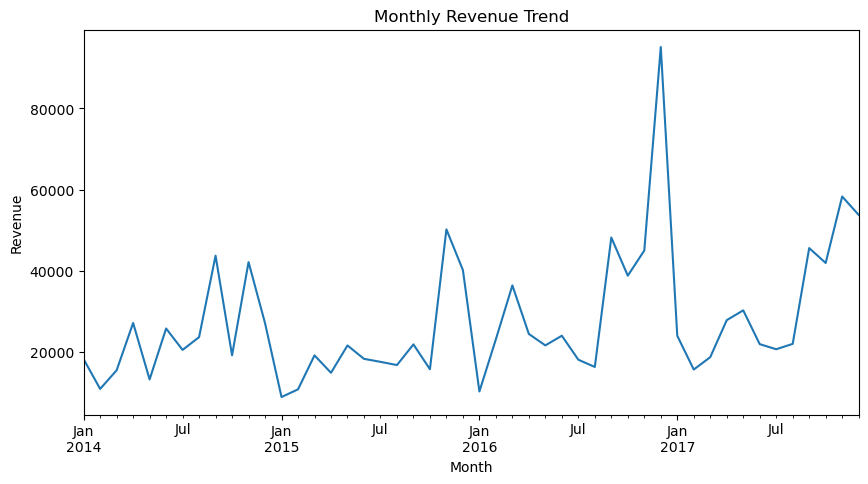

In [16]:
monthly_revenue = df.groupby(df['Order Date'].dt.to_period('M'))['Revenue'].sum()

monthly_revenue.plot(kind='line', figsize=(10,5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

## BUSINESS INSIGHT

* Shows:

   * sales growth
   * seasonal trends
   * high and low revenue months

# Revenue by Category (BAR CHART)

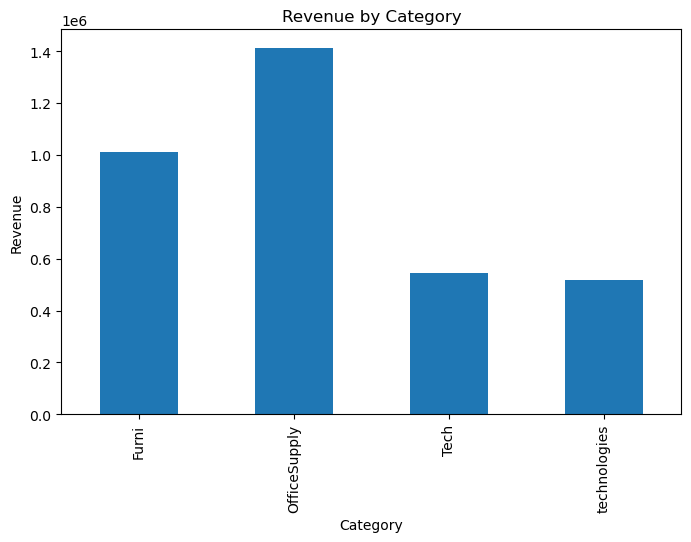

In [20]:
category_revenue = df.groupby('Category')['Revenue'].sum()

category_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

# BUSINESS INSIGHT

* Shows:

   * best-performing category
   * product contribution
   * category profitability

# Repeat vs One-Time Customers (PIE CHART)

In [21]:
# Count Orders Per Customer
customer_orders = df.groupby('Customer ID')['Order ID'].count()

In [22]:
customer_orders

Customer ID
AA-10315    17
AA-10375    19
AA-10480    13
AA-10645    21
AB-10015    11
            ..
XP-21865    29
YC-21895    12
YS-21880    15
ZC-21910    31
ZD-21925    12
Name: Order ID, Length: 793, dtype: int64

In [23]:
# Separate Repeat and One-Time Customers
repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

In [25]:
print(repeat_customers)
print(one_time_customers)

793
0


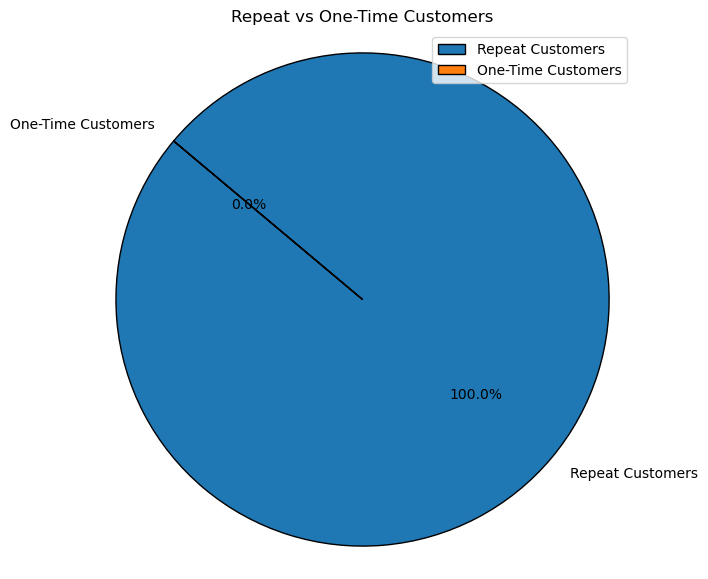

In [29]:
labels = ['Repeat Customers', 'One-Time Customers']

sizes = [repeat_customers, one_time_customers]

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'black'}
)

plt.legend(labels, loc='upper right')

plt.title('Repeat vs One-Time Customers')

plt.axis('equal')

plt.show()

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed on the Superstore Sales Performances and Analysis Dataset to analyze sales performance, customer behavior, product profitability, and regional trends using Python, Pandas, and Matplotlib.

* The dataset was cleaned by:

  * removing cancelled orders and negative quantities,
  * handling missing values,
  * correcting Region values using state mapping,
  * converting Order Date into proper datetime format.
* EDA techniques such as:
   * statistical summary,
   * groupby analysis,
   * trend analysis,
   * customer segmentation
were used to understand the dataset.
* The following visualizations were created:
   * Monthly Revenue Trend (Line Chart)
   * Revenue by Category (Bar Chart)
   * Repeat vs One-Time Customers (Pie Chart)
* Key Insights
   * Revenue showed monthly fluctuations and seasonal trends.
   * Some product categories generated higher revenue than others.
   * A small number of products contributed significantly to total sales.
   * Repeat customers played an important role in business revenue.
   * Regional sales performance varied across different regions.

The EDA process helped identify business trends, customer behavior, and profitable products, supporting better business decision-making.
